In [ ]:
    !pip install -qq pydantic-ai serpapi pydantic-graph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.5/90.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.8/210.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 52.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.27.0, but you have google-auth 2.38.0 which is incompatible.


In [ ]:
from openai import AsyncAzureOpenAI
from google.colab import userdata

from pprint import pprint
import json
import random
import httpx

import nest_asyncio
from IPython.display import Image
from dataclasses import dataclass
from IPython.display import Markdown, display, clear_output

import numpy as np

from typing import Literal, Union, List, Tuple

from rich.prompt import Prompt

from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIModel
from pydantic import BaseModel, Field
from pydantic_ai import Agent, RunContext
from pydantic_ai.messages import ModelMessage
from pydantic_ai.result import Usage, UsageLimits

import serpapi

from __future__ import annotations

from dataclasses import dataclass, field
from pydantic import BaseModel, EmailStr
from pydantic_ai.format_as_xml import format_as_xml
from pydantic_graph import BaseNode, End, Graph, GraphRunContext

In [ ]:
 async_azure_client = AsyncAzureOpenAI(api_key=userdata.get('AZURE_API_KEY'), azure_endpoint=userdata.get('AZURE_BASE_URL'), api_version=userdata.get('AZURE_API_VERSION'))
nest_asyncio.apply()
model = OpenAIModel('gpt-4o', openai_client=async_azure_client)

In [ ]:
@dataclass
class DivisibleBy5(BaseNode[None, None, int]):
    foo: int

    async def run(self,ctx: GraphRunContext,) -> Increment | End[int]:
        if self.foo % 5 == 0:
            return End(self.foo)
        else:
            return Increment(self.foo)


@dataclass
class Increment(BaseNode):
    foo: int

    async def run(self, ctx: GraphRunContext) -> DivisibleBy5:
        return DivisibleBy5(self.foo + 1)


fives_graph = Graph(nodes=[DivisibleBy5, Increment])
result, history = fives_graph.run_sync(DivisibleBy5(4))
print(result)

print([item.data_snapshot() for item in history])

5
[DivisibleBy5(foo=4), Increment(foo=4), DivisibleBy5(foo=5), End(data=5)]


In [ ]:
print(fives_graph.mermaid_code(start_node=DivisibleBy5))

---
title: fives_graph
---
stateDiagram-v2
  [*] --> DivisibleBy5
  DivisibleBy5 --> Increment
  DivisibleBy5 --> [*]
  Increment --> DivisibleBy5


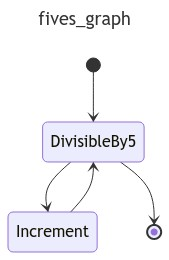

In [ ]:
Image(fives_graph.mermaid_image(start_node=DivisibleBy5))

In [ ]:
@dataclass
class MachineState:
    user_balance: float = 0.0
    product: str | None = None


@dataclass
class InsertCoin(BaseNode[MachineState]):
    async def run(self, ctx: GraphRunContext[MachineState]) -> CoinsInserted:
        return CoinsInserted(float(Prompt.ask('Insert coins')))


@dataclass
class CoinsInserted(BaseNode[MachineState]):
    amount: float

    async def run(
        self, ctx: GraphRunContext[MachineState]
    ) -> SelectProduct | Purchase:
        ctx.state.user_balance += self.amount
        if ctx.state.product is not None:
            return Purchase(ctx.state.product)
        else:
            return SelectProduct()


@dataclass
class SelectProduct(BaseNode[MachineState]):
    async def run(self, ctx: GraphRunContext[MachineState]) -> Purchase:
        return Purchase(Prompt.ask('Select product'))


PRODUCT_PRICES = {
    'water': 1.25,
    'soda': 1.50,
    'crisps': 1.75,
    'chocolate': 2.00,
}


@dataclass
class Purchase(BaseNode[MachineState, None, None]):
    product: str

    async def run(self, ctx: GraphRunContext[MachineState]) -> End | InsertCoin | SelectProduct:
        if price := PRODUCT_PRICES.get(self.product):
            ctx.state.product = self.product
            if ctx.state.user_balance >= price:
                ctx.state.user_balance -= price
                return End(None)
            else:
                diff = price - ctx.state.user_balance
                print(f'Not enough money for {self.product}, need {diff:0.2f} more')
                #> Not enough money for crisps, need 0.75 more
                return InsertCoin()
        else:
            print(f'No such product: {self.product}, try again')
            return SelectProduct()


vending_machine_graph = Graph(
    nodes=[InsertCoin, CoinsInserted, SelectProduct, Purchase]
)

In [ ]:
state = MachineState()
await vending_machine_graph.run(InsertCoin(), state=state)
print(f'purchase successful item={state.product} change={state.user_balance:0.2f}')

Insert coins:

0.3


Select product:

soda
Not enough money for soda, need 1.20 more


Insert coins:

1.5
purchase successful item=soda change=0.30


In [ ]:
state = MachineState()
await vending_machine_graph.run(InsertCoin(), state=state)
print(f'purchase successful item={state.product} change={state.user_balance:0.2f}')

Insert coins:

0.25


Select product:

cripsp
No such product: cripsp, try again


Select product:

...

0.1
Not enough money for crisps, need 0.40 more


Insert coins:

0.1
Not enough money for crisps, need 0.30 more


Insert coins:

1.0
purchase successful item=crisps change=0.70


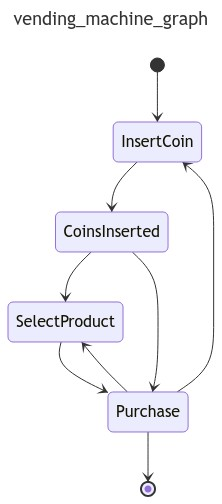

In [ ]:
Image(vending_machine_graph.mermaid_image(start_node=InsertCoin))

In [ ]:
@dataclass
class User:
    name: str
    email: EmailStr
    interests: list[str]


@dataclass
class Email:
    subject: str
    body: str


@dataclass
class State:
    user: User
    write_agent_messages: list[ModelMessage] = field(default_factory=list)


email_writer_agent = Agent(
    model=model,
    result_type=Email,
    system_prompt='Write a welcome email to our tech blog.',
)


@dataclass
class WriteEmail(BaseNode[State]):
    email_feedback: str | None = None

    async def run(self, ctx: GraphRunContext[State]) -> Feedback:
        if self.email_feedback:
            prompt = (
                f'Rewrite the email for the user:\n'
                f'{format_as_xml(ctx.state.user)}\n'
                f'Feedback: {self.email_feedback}'
            )
        else:
            prompt = (
                f'Write a welcome email for the user:\n'
                f'{format_as_xml(ctx.state.user)}'
            )

        result = await email_writer_agent.run(
            prompt,
            message_history=ctx.state.write_agent_messages,
        )
        ctx.state.write_agent_messages += result.all_messages()
        return Feedback(result.data)


class EmailRequiresWrite(BaseModel):
    feedback: str


class EmailOk(BaseModel):
    pass


feedback_agent = Agent[None, EmailRequiresWrite | EmailOk](
    model,
    result_type=EmailRequiresWrite | EmailOk,  # type: ignore
    system_prompt=(
        'Review the email and provide feedback, email must reference the users specific interests.'
    ),
)


@dataclass
class Feedback(BaseNode[State, None, Email]):
    email: Email

    async def run(self,ctx: GraphRunContext[State],) -> WriteEmail | End[Email]:
        prompt = format_as_xml({'user': ctx.state.user, 'email': self.email})
        result = await feedback_agent.run(prompt)
        if isinstance(result.data, EmailRequiresWrite):
            return WriteEmail(email_feedback=result.data.feedback)
        else:
            return End(self.email)


user = User(
    name='John Doe',
    email='john.joe@exmaple.com',
    interests=['Haskel', 'Lisp', 'Fortran'],
)
statdsxzh,e = State(user)
feedback_graph = Graph(nodes=(WriteEmail, Feedback))
email, _ = await feedback_graph.run(WriteEmail(), state=state)
print(email)

Email(subject='Welcome to Our Tech Blog, John Doe!', body="Hi John Doe,\n\nWelcome to our Tech Blog! We're thrilled to have you join our community. With your interests in Haskell, Lisp, and Fortran, we believe you'll find our content both engaging and insightful.\n\nHere's what you can expect from our blog:\n\n- In-depth articles and tutorials on the latest in Haskell, Lisp, Fortran, and other programming languages.\n- Expert opinions and discussions on cutting-edge technology trends.\n- Tips and tricks to enhance your coding skills and knowledge.\n\nTo get started, check out our latest posts, join the conversation in the comments section, and feel free to share your thoughts and ideas.\n\nIf you have any questions or need assistance, our team is here to help. Just reply to this email or reach out to us through our contact page.\n\nHappy reading and coding!\n\nBest regards,\nThe Tech Blog Team")


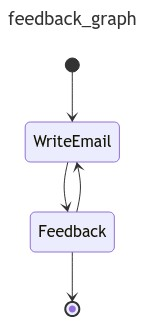

In [ ]:
Image(feedback_graph.mermaid_image(start_node=WriteEmail))

In [ ]:
@dataclass
class QuestionState:
    question: str | None = None
    ask_agent_messages: list[ModelMessage] = field(default_factory=list)
    evaluate_agent_messages: list[ModelMessage] = field(default_factory=list)

ask_agent = Agent(model=model, result_type=str)

@dataclass
class Ask(BaseNode[QuestionState]):
    async def run(self, ctx: GraphRunContext[QuestionState]) -> Answer:
        result = await ask_agent.run(
            'Ask a simple question with a single correct answer.',
            message_history=ctx.state.ask_agent_messages,
        )
        ctx.state.ask_agent_messages += result.all_messages()
        ctx.state.question = result.data
        return Answer(result.data)


@dataclass
class Answer(BaseNode[QuestionState]):
    question: str
    answer: str | None = None

    async def run(self, ctx: GraphRunContext[QuestionState]) -> Evaluate:
        assert self.answer is not None
        return Evaluate(self.answer)


@dataclass
class EvaluationResult:
    correct: bool
    comment: str


evaluate_agent = Agent(
    model=model,
    result_type=EvaluationResult,
    system_prompt='Given a question and answer, evaluate if the answer is correct.',
)


@dataclass
class Evaluate(BaseNode[QuestionState]):
    answer: str

    async def run( self, ctx: GraphRunContext[QuestionState], ) -> End[str] | Reprimand:
        assert ctx.state.question is not None
        result = await evaluate_agent.run(
            format_as_xml({'question': ctx.state.question, 'answer': self.answer}),
            message_history=ctx.state.evaluate_agent_messages,
        )
        ctx.state.evaluate_agent_messages += result.all_messages()
        if result.data.correct:
            return End(result.data.comment)
        else:
            return Reprimand(result.data.comment)


@dataclass
class Reprimand(BaseNode[QuestionState]):
    comment: str

    async def run(self, ctx: GraphRunContext[QuestionState]) -> Ask:
        print(f'Comment: {self.comment}')
        ctx.state.question = None
        return Ask()



In [ ]:
question_graph = Graph(nodes=(Ask, Answer, Evaluate, Reprimand))
state = QuestionState()
node = Ask()
history: list[HistoryStep[QuestionState]] = []
while True:
    node = await question_graph.next(node, history, state=state)
    if isinstance(node, Answer):
        node.answer = Prompt.ask(node.question)
    elif isinstance(node, End):
        print(f'Correct answer! {node.data}')
        print([e.data_snapshot() for e in history])
        break

What is the capital of France?:

rome
Comment: The answer is incorrect. The capital of France is Paris.


What is 2 + 2?:

40
Comment: The answer is incorrect. 2 + 2 equals 4.


What is the boiling point of water at sea level in degrees Celsius?:

0
Comment: The answer is incorrect. The boiling point of water at sea level is 100 degrees Celsius.


What is the largest planet in our solar system?:

Ag
Comment: The answer is incorrect. The largest planet in our solar system is Jupiter.


What is the chemical symbol for water?:

h2o
Correct answer! The answer is correct. The chemical symbol for water is H2O.
[Ask(), Answer(question='What is the capital of France?', answer='rome'), Evaluate(answer='rome'), Reprimand(comment='The answer is incorrect. The capital of France is Paris.'), Ask(), Answer(question='What is 2 + 2?', answer='40'), Evaluate(answer='40'), Reprimand(comment='The answer is incorrect. 2 + 2 equals 4.'), Ask(), Answer(question='What is the boiling point of water at sea level in degrees Celsius?', answer='0'), Evaluate(answer='0'), Reprimand(comment='The answer is incorrect. The boiling point of water at sea level is 100 degrees Celsius.'), Ask(), Answer(question='What is the largest planet in our solar system?', answer='Ag'), Evaluate(answer='Ag'), Reprimand(comment='The answer is incorrect. The largest planet in our solar system is Jupiter.'), Ask(), Answer(question='What is the chemical symbol for water?', answer='h2o'), Evaluate(answer='h2o')]


In [ ]:
for e in history:
    print(e.data_snapshot())

Ask()
Answer(question='What is the capital of France?', answer='rome')
Evaluate(answer='rome')
Reprimand(comment='The answer is incorrect. The capital of France is Paris.')
Ask()
Answer(question='What is 2 + 2?', answer='40')
Evaluate(answer='40')
Reprimand(comment='The answer is incorrect. 2 + 2 equals 4.')
Ask()
Answer(question='What is the boiling point of water at sea level in degrees Celsius?', answer='0')
Evaluate(answer='0')
Reprimand(comment='The answer is incorrect. The boiling point of water at sea level is 100 degrees Celsius.')
Ask()
Answer(question='What is the largest planet in our solar system?', answer='Ag')
Evaluate(answer='Ag')
Reprimand(comment='The answer is incorrect. The largest planet in our solar system is Jupiter.')
Ask()
Answer(question='What is the chemical symbol for water?', answer='h2o')
Evaluate(answer='h2o')


In [ ]:
print(question_graph.mermaid_code(start_node=Ask))

---
title: question_graph
---
stateDiagram-v2
  [*] --> Ask
  Ask --> Answer
  Answer --> Evaluate
  Evaluate --> Reprimand
  Evaluate --> [*]
  Reprimand --> Ask


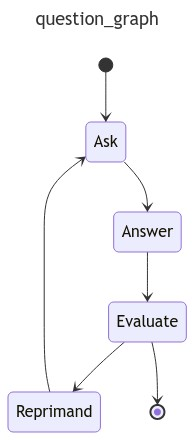

In [ ]:
Image(question_graph.mermaid_image(start_node=Ask))

In [ ]:
format_as_xml({'data':'... data ...'})

'<examples>\n  <data>... data ...</data>\n</examples>'

In [ ]:
# from pydantic_ai.fo

# Shopping cart system

Current items in your cart: ['Apple', 'Orange', 'Orange']
Total price: $4.00
Thank you for your purchase!
--------------------------------------------------
AddItem(item='Apple', price=1.0)
AddItem(item='Orange', price=2.0)
AddItem(item='Orange', price=1.0)
ViewCart(items=['Apple', 'Orange', 'Orange'], total_price=4.0)
Checkout()


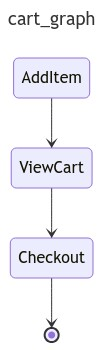

In [ ]:
@dataclass
class CartState:
    items: list[str] = field(default_factory=list)
    total_price: float = 0.0

@dataclass
class AddItem(BaseNode[CartState]):
    item: str
    price: float

    async def run(self, ctx: GraphRunContext[CartState]) -> ViewCart:
        ctx.state.items.append(self.item)
        ctx.state.total_price += self.price
        return ViewCart(ctx.state.items, ctx.state.total_price)

@dataclass
class ViewCart(BaseNode[CartState]):
    items: list[str]
    total_price: float

    async def run(self, ctx: GraphRunContext[CartState]) -> Checkout:
        print(f"Current items in your cart: {self.items}")
        print(f"Total price: ${self.total_price:.2f}")
        return Checkout()

@dataclass
class Checkout(BaseNode[CartState]):
    async def run(self, ctx: GraphRunContext[CartState]) -> End[str]:
        return End("Thank you for your purchase!")

cart_graph = Graph(nodes=(AddItem, ViewCart, Checkout))
cart_state = CartState()

node = AddItem(item="Apple", price=1.0)
history: list[HistoryStep[CartState]] = []

while True:
    node = await cart_graph.next(node, history, state=cart_state)

    if isinstance(node, ViewCart):
        if len(cart_state.items) < 3:
            item = random.choice(['Apple', 'Banana', 'Orange'])
            price = random.choice([1.0, 1.5, 2.0])
            node = AddItem(item=item, price=price)
        else:
            node = ViewCart(cart_state.items, cart_state.total_price)

    elif isinstance(node, End):
        print(node.data)
        break
print('-'*50)
for e in history:
    print(e.data_snapshot())

Image(cart_graph.mermaid_image())

Current tasks: ['Write report', 'Task 2', 'Task 3', 'Task 4', 'Task 5']
Task 'Write report' completed!
Task 'Task 2' completed!
Task 'Task 3' completed!
Task 'Task 4' completed!
Task 'Task 5' completed!
--------------------------------------------------
AddTask(task='Write report')
AddTask(task='Task 2')
AddTask(task='Task 3')
AddTask(task='Task 4')
AddTask(task='Task 5')
ViewTasks(tasks=[])
CompleteTask(task='Write report')
CompleteTask(task='Task 2')
CompleteTask(task='Task 3')
CompleteTask(task='Task 4')
CompleteTask(task='Task 5')


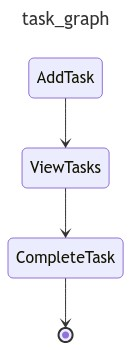

In [ ]:
@dataclass
class TaskState:
    tasks: list[str] = field(default_factory=list)

@dataclass
class AddTask(BaseNode[TaskState]):
    task: str

    async def run(self, ctx: GraphRunContext[TaskState]) -> ViewTasks:
        ctx.state.tasks.append(self.task)
        return ViewTasks(ctx.state.tasks)

@dataclass
class ViewTasks(BaseNode[TaskState]):
    tasks: list[str]

    async def run(self, ctx: GraphRunContext[TaskState]) -> CompleteTask:
        print(f"Current tasks: {self.tasks}")
        return CompleteTask(task=self.tasks[0])  # Complete the first task

@dataclass
class CompleteTask(BaseNode[TaskState]):
    task: str

    async def run(self, ctx: GraphRunContext[TaskState]) -> End[str]:
        ctx.state.tasks.remove(self.task)
        return End(f"Task '{self.task}' completed!")

task_graph = Graph(nodes=(AddTask, ViewTasks, CompleteTask))
task_state = TaskState()

node = AddTask(task="Write report")
history: list[HistoryStep[TaskState]] = []

# Simulating user interaction
task_limit = 5  # Limit the number of tasks to add
task_count = 1  # Start with the first task

while True:
    node = await task_graph.next(node, history, state=task_state)

    if isinstance(node, ViewTasks):
        if task_count < task_limit:
            task_count += 1
            node = AddTask(task=f"Task {task_count}")
        else:
            node = ViewTasks(task_state.tasks)
    elif isinstance(node, End):
        print(node.data)
        if len(task_state.tasks) == 0:
            break
        else:
            node = CompleteTask(task=task_state.tasks[0])


print('-'*50)
for e in history:
    print(e.data_snapshot())

Image(task_graph.mermaid_image())

# Internet Insigths

In [ ]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

@dataclass
class InsightState:
    topic: str | None = None
    references: list[str] = field(default_factory=list)
    insigths: list[str] = field(default_factory=list)
    internet_messages: list[ModelMessage] = field(default_factory=list)
    insights_messages: list[ModelMessage] = field(default_factory=list)

@dataclass
class Topic(BaseNode[InsightState]):
    topic : str
    async def run(self, ctx: GraphRunContext[InsightState]) -> RetrieveReferences:
        ctx.state.topic = self.topic
        return RetrieveReferences()


class Serpapi:
    client = serpapi.Client(api_key=userdata.get('SERPAPI_API_KEY'))
    @classmethod
    def generate_date_frame(cls, **kwargs)->str: # 2024-01-01..2024-02-01
        kwargs = kwargs or {"months":1}
        end_date = datetime.now()
        start_date = end_date - relativedelta(**kwargs)
        return f"{start_date.strftime('%Y-%m-%d')}..{end_date.strftime('%Y-%m-%d')}"

    @classmethod
    async def search_topic_until_today(cls, *, question: str, date_frame:str) -> List[tuple] | None:
        duckduckgo_results = cls.client.search({
            'engine': 'duckduckgo',
            'q': question,
            'df': cls.generate_date_frame(**json.loads(date_frame))
        })
        if duckduckgo_results:
            return list(map(lambda x: (x['snippet'],x['link']), duckduckgo_results['organic_results']))

@dataclass
class SupportInternetDependencies:
    serpapi_client: Serpapi

internet_agent = Agent(model=model, result_type=List[tuple])
@internet_agent.tool
async def search_news(ctx: RunContext[SupportInternetDependencies], topic: str, date_frame:str) -> str:
    """
    Args:
        date_frame: A limit of days,months,weeks before today, format in json like {"days":1}, {"months":1}, {"weeks":1}, {"months":1, "weeks":1, "days":1}
    """
    print('Running search_news tool ...')
    return await ctx.deps.serpapi_client.search_topic_until_today(question=topic, date_frame=date_frame)



retrieve_deps = SupportInternetDependencies(serpapi_client=Serpapi())
@dataclass
class RetrieveReferences(BaseNode[InsightState]):

    async def run(self, ctx: GraphRunContext[InsightState]) -> GenerateInsights:
        assert ctx.state.topic is not None
        result = await internet_agent.run(f'Retrieve current news for "{ctx.state.topic}"', deps=retrieve_deps)
        for snippet,link in result.data:
            ctx.state.references.append({'link':link,'snippet':snippet})
        ctx.state.internet_messages += result.all_messages()
        return GenerateInsights()

insights_agent = Agent(model=model, result_type=List[str])
@dataclass
class GenerateInsights(BaseNode[InsightState]):

    async def run(self, ctx: GraphRunContext[InsightState]) -> End[str]:
        result = await insights_agent.run(f'Generate some insights from the context: {str(ctx.state.references)}')
        ctx.state.insigths = result.data
        ctx.state.insights_messages += result.all_messages()
        insights = "\n- ".join(ctx.state.insigths)
        return End(f"The insights for '{ctx.state.topic}' using {len(ctx.state.references)} references:\n\n{insights}")

insight_graph = Graph(nodes=(Topic, RetrieveReferences, GenerateInsights))
state = InsightState()
node = Topic(topic='machine learning')
history: list[HistoryStep[InsightState]] = []
while True:
    node = await insight_graph.next(node, history, state=state)
    if isinstance(node, BaseNode):
        print(f'Running {type(node)} ...')
    elif isinstance(node, End):
        print(f'{node.data}')
        print('-'*50)
        print([e.data_snapshot() for e in history])
        break

Running <class '__main__.RetrieveReferences'> ...
Running search_news tool ...
Running <class '__main__.GenerateInsights'> ...
The insights for 'machine learning' using 10 references:

Machine learning algorithms are extensively used to analyze patterns, such as spending patterns and transaction timing, to detect anomalies. This is akin to a high-tech firewall that is constantly monitoring for unusual activity.
- Machine learning can be categorized into three main types depending on the algorithms and data scales used. Deep learning, which is often used interchangeably with machine learning, is actually a subset of neural networks, which, in turn, are a subset of machine learning. All these are subsets of artificial intelligence (AI).
- Machine learning's versatility allows it to be applied in various fields such as healthcare diagnostics and personalized marketing, making it a key component of technological advancement.
- Tools like PyCharm, especially with Jupyter notebooks, facilita

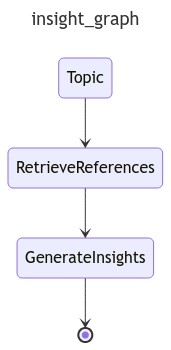

In [ ]:
Image(insight_graph.mermaid_image())

In [ ]:
state.topic

'machine learning'

In [ ]:
state.references

[{'link': 'https://www.techradar.com/pro/what-is-machine-learning',
  'snippet': "Machine learning algorithms analyze spending patterns, shopping locations, and transaction timing to detect anything unusual. It's like having a high-tech firewall constantly scanning and ..."},
 {'link': 'https://www.ibm.com/think/topics/cpu-vs-gpu-machine-learning',
  'snippet': 'Machine learning can be broken down into three main types depending on the types of algorithms employed and the scale of the data used. While the term deep learning is often used interchangeably with machine learning, deep learning is a subset of neural networks, and neural networks are a subset of machine learning.. All three terms can be considered subsets of artificial intelligence (AI ...'},
 {'link': 'https://aimagazine.com/top10/top-10-global-machine-learning-companies',
  'snippet': "Machine learning, a form of AI that uses data to learn without the need for explicit programming, has become a cornerstone of technological

In [ ]:
state.insigths

['Machine learning algorithms are extensively used to analyze patterns, such as spending patterns and transaction timing, to detect anomalies. This is akin to a high-tech firewall that is constantly monitoring for unusual activity.',
 'Machine learning can be categorized into three main types depending on the algorithms and data scales used. Deep learning, which is often used interchangeably with machine learning, is actually a subset of neural networks, which, in turn, are a subset of machine learning. All these are subsets of artificial intelligence (AI).',
 "Machine learning's versatility allows it to be applied in various fields such as healthcare diagnostics and personalized marketing, making it a key component of technological advancement.",
 'Tools like PyCharm, especially with Jupyter notebooks, facilitate organizing and managing complex anomaly detection projects which involve large datasets.',
 'Capable machine learning models, particularly with Trusted Capable Model Environm

In [ ]:
state.internet_messages

[ModelRequest(parts=[UserPromptPart(content='Retrieve current news for "machine learning"', timestamp=datetime.datetime(2025, 1, 16, 16, 32, 41, 136918, tzinfo=datetime.timezone.utc), part_kind='user-prompt')], kind='request'),
 ModelResponse(parts=[ToolCallPart(tool_name='search_news', args=ArgsJson(args_json='{"topic":"machine learning","date_frame":"{\\"days\\":1}"}'), tool_call_id='call_Z6JREJu56bVvDpp1zLBjP7ia', part_kind='tool-call')], timestamp=datetime.datetime(2025, 1, 16, 16, 32, 41, tzinfo=datetime.timezone.utc), kind='response'),
 ModelRequest(parts=[ToolReturnPart(tool_name='search_news', content=[("Machine learning algorithms analyze spending patterns, shopping locations, and transaction timing to detect anything unusual. It's like having a high-tech firewall constantly scanning and ...", 'https://www.techradar.com/pro/what-is-machine-learning'), ('Machine learning can be broken down into three main types depending on the types of algorithms employed and the scale of the 

In [ ]:
state.insights_messages

[ModelRequest(parts=[UserPromptPart(content='Generate some insights from the context: [{\'link\': \'https://www.techradar.com/pro/what-is-machine-learning\', \'snippet\': "Machine learning algorithms analyze spending patterns, shopping locations, and transaction timing to detect anything unusual. It\'s like having a high-tech firewall constantly scanning and ..."}, {\'link\': \'https://www.ibm.com/think/topics/cpu-vs-gpu-machine-learning\', \'snippet\': \'Machine learning can be broken down into three main types depending on the types of algorithms employed and the scale of the data used. While the term deep learning is often used interchangeably with machine learning, deep learning is a subset of neural networks, and neural networks are a subset of machine learning.. All three terms can be considered subsets of artificial intelligence (AI ...\'}, {\'link\': \'https://aimagazine.com/top10/top-10-global-machine-learning-companies\', \'snippet\': "Machine learning, a form of AI that uses

In [ ]:
history

[NodeStep(state=InsightState(topic='machine learning', references=[], insigths=[], internet_messages=[], insights_messages=[]), node=Topic(topic='machine learning'), start_ts=datetime.datetime(2025, 1, 16, 16, 32, 41, 135942, tzinfo=datetime.timezone.utc), duration=3.880999997818435e-06, kind='node'),
 NodeStep(state=InsightState(topic='machine learning', references=[{'link': 'https://www.techradar.com/pro/what-is-machine-learning', 'snippet': "Machine learning algorithms analyze spending patterns, shopping locations, and transaction timing to detect anything unusual. It's like having a high-tech firewall constantly scanning and ..."}, {'link': 'https://www.ibm.com/think/topics/cpu-vs-gpu-machine-learning', 'snippet': 'Machine learning can be broken down into three main types depending on the types of algorithms employed and the scale of the data used. While the term deep learning is often used interchangeably with machine learning, deep learning is a subset of neural networks, and neu